<a href="https://colab.research.google.com/github/Alltingzrpozz/Alltingzrpozz/blob/main/Image_Processing_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library Imports

In [18]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from graphviz import Digraph
from IPython.display import display, Image

# Data Loading

In [19]:
print("--- 2. Data Loading & Sanity Checks ---")
# Using relative paths - file directory
train_df = pd.read_csv('/content/sample_data/train.csv')
TRAIN_IMG_DIR = '/content/drive/MyDrive/Study/MSc AI/Modules /Applied AI/Lectures/Week 4/data (1)/train_images'

print("\nDataset Structure (train.csv):")
train_df.info()
print("\nClass Distribution:")
display(train_df['label'].value_counts())

--- 2. Data Loading & Sanity Checks ---

Dataset Structure (train.csv):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      10000 non-null  int64 
 1   label   10000 non-null  object
dtypes: int64(1), object(1)
memory usage: 156.4+ KB

Class Distribution:


,count
label,
dog,5011
cat,4989


# Exploratory Data Analysis (EDA)

--- 3. Exploratory Data Analysis (EDA) ---


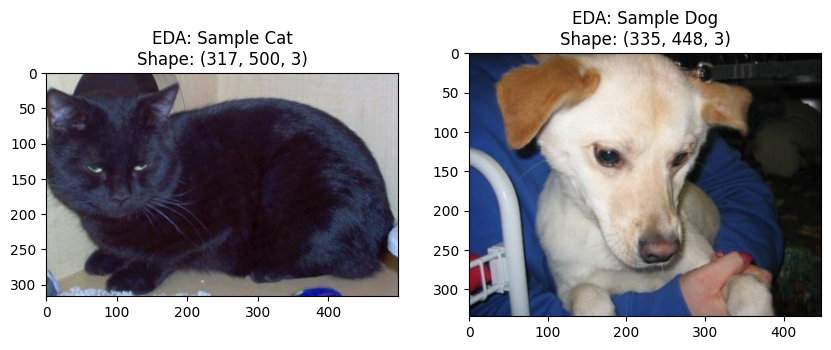

In [23]:
print("--- 3. Exploratory Data Analysis (EDA) ---")
sample_cat = train_df[train_df['label'] == 'cat'].iloc[0]
sample_dog = train_df[train_df['label'] == 'dog'].iloc[0]

img_cat = cv2.imread(os.path.join(TRAIN_IMG_DIR, str(sample_cat['id']) + '.jpg'))
img_dog = cv2.imread(os.path.join(TRAIN_IMG_DIR, str(sample_dog['id']) + '.jpg'))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img_cat, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"EDA: Sample Cat\nShape: {img_cat.shape}")
axes[1].imshow(cv2.cvtColor(img_dog, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"EDA: Sample Dog\nShape: {img_dog.shape}")
plt.show()

# Pre-processing & Feature Extraction (HOG)

In [24]:
print("--- 4. Pre-processing & Feature Extraction ---")
IMG_SIZE = (64, 64)
X_features = []
y_labels = train_df['label'].values

print("Extracting HOG features from images. This will take a moment...")
for index, row in train_df.iterrows():
    img_path = os.path.join(TRAIN_IMG_DIR, str(row['id']) + '.jpg')
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    features, hog_image = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), visualize=True)
    X_features.append(features)

X = np.array(X_features)
y = np.array(y_labels)

print(f"\nSANITY CHECK: Feature matrix X shape: {X.shape}")

--- 4. Pre-processing & Feature Extraction ---
Extracting HOG features from images. This will take a moment...

SANITY CHECK: Feature matrix X shape: (10000, 1764)


# Data Split

In [25]:
print("--- 5. Data Splitting ---")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=100)
print(f"X_train shape: {X_train.shape} | X_val shape: {X_val.shape}")

--- 5. Data Splitting ---
X_train shape: (7000, 1764) | X_val shape: (3000, 1764)


# Modelling & Evaluation

--- 6. Modelling & Critical Evaluation ---
SVM Validation Accuracy: 0.6973
Random Forest Validation Accuracy: 0.7040

WINNER: Random Forest!


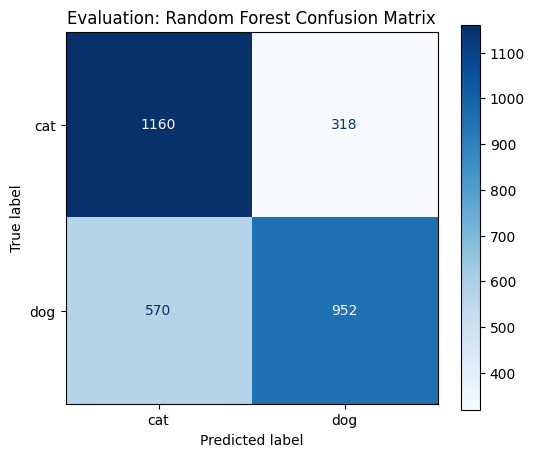

In [26]:
print("--- 6. Modelling & Critical Evaluation ---")

# Model 1: Linear Support Vector Classifier
svm_model = LinearSVC(random_state=100, max_iter=2000)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_val)
svm_acc = accuracy_score(y_val, svm_preds)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)
rf_acc = accuracy_score(y_val, rf_preds)

print(f"SVM Validation Accuracy: {svm_acc:.4f}")
print(f"Random Forest Validation Accuracy: {rf_acc:.4f}")

best_model = svm_model if svm_acc > rf_acc else rf_model
best_name = "LinearSVC" if svm_acc > rf_acc else "Random Forest"
print(f"\nWINNER: {best_name}!")

# Confusion Matrix
cm = confusion_matrix(y_val, best_model.predict(X_val), labels=['cat', 'dog'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['cat', 'dog'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title(f'Evaluation: {best_name} Confusion Matrix')
plt.show()

# Final Test Predictions & CSV Export

In [28]:
print("--- 7. Final Predictions for Submission ---")
# Using relative paths for the test data
test_df = pd.read_csv('/content/drive/MyDrive/Study/MSc AI/Modules /Applied AI/Lectures/Week 4/data (1)/test.csv')
# TEST_IMG_DIR path
TEST_IMG_DIR = '/content/drive/MyDrive/Study/MSc AI/Modules /Applied AI/Lectures/Week 4/data (1)/test_images'

test_features = []
print("Processing test images...")
for index, row in test_df.iterrows():
    img_path = os.path.join(TEST_IMG_DIR, str(row['id']) + '.jpg')
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    features = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=False)
    test_features.append(features)

X_test_final = np.array(test_features)
final_predictions = best_model.predict(X_test_final)

# Create submission dataframe and save locally
submission_df = pd.DataFrame({'id': test_df['id'], 'label': final_predictions})
submission_df.to_csv('image_predictions.csv', index=False)
print("Success: 'image_predictions.csv' generated in the current directory.")

--- 7. Final Predictions for Submission ---
Processing test images...
Success: 'image_predictions.csv' generated in the current directory.


# Image Pipeline Flowchart

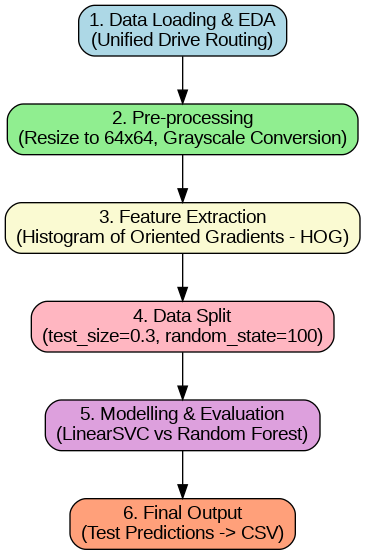

In [29]:
img_pipeline = Digraph(comment='Image Processing Pipeline')
img_pipeline.attr(rankdir='TB', size='8,8')
img_pipeline.node_attr.update(shape='box', style='rounded,filled', fontname='Helvetica')

img_pipeline.node('A', '1. Data Loading & EDA\n(Unified Drive Routing)', fillcolor='lightblue')
img_pipeline.node('B', '2. Pre-processing\n(Resize to 64x64, Grayscale Conversion)', fillcolor='lightgreen')
img_pipeline.node('C', '3. Feature Extraction\n(Histogram of Oriented Gradients - HOG)', fillcolor='lightgoldenrodyellow')
img_pipeline.node('D', '4. Data Split\n(test_size=0.3, random_state=100)', fillcolor='lightpink')
img_pipeline.node('E', '5. Modelling & Evaluation\n(LinearSVC vs Random Forest)', fillcolor='plum')
img_pipeline.node('F', '6. Final Output\n(Test Predictions -> CSV)', fillcolor='lightsalmon')

img_pipeline.edges(['AB', 'BC', 'CD', 'DE', 'EF'])
img_pipeline.render('img_pipeline_flowchart', format='png', cleanup=True)
display(Image(filename='img_pipeline_flowchart.png'))